### Bulid a basic chat bot

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15'}}, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002E2D95363C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002E2D95370E0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15'}}, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002E2D9547250>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002E2D9547C50>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [12]:
def chatbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [17]:
graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot", chatbot)
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph = graph_builder.compile()

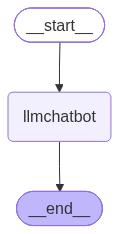

In [18]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [22]:
response=graph.invoke({"messages":"Hi"})
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='c97a93c3-502d-416d-9395-934ff3b1483c'),
 AIMessage(content='How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.010031646, 'completion_tokens_details': None, 'prompt_time': 0.001624869, 'prompt_tokens_details': None, 'queue_time': 0.159239215, 'total_time': 0.011656515}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ffeeb-8cf7-7610-a5c7-a8ba362fcd31-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]

In [23]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='c97a93c3-502d-416d-9395-934ff3b1483c'),
  AIMessage(content='How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.010031646, 'completion_tokens_details': None, 'prompt_time': 0.001624869, 'prompt_tokens_details': None, 'queue_time': 0.159239215, 'total_time': 0.011656515}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ffeeb-8cf7-7610-a5c7-a8ba362fcd31-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}

In [24]:
for event in graph.stream({"messages": "Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a computer program, so I don't have feelings, but thank you for asking. I'm functioning properly and ready to help with any questions or tasks you have. How can I assist you today?


### chatbot with tool

In [ ]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgragh")

{'query': 'What is langgragh',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control.',
   'score': 0.94109917,
   'raw_content': None,
   'id': '84db38-00'},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manne

In [54]:
### custom function
def division(a:int, b:int)->int:
    """Divide a and b
    Args:
        a (int): first int
        b (int): second int
    Returns:
        int: output int
    """
    return a / b

In [55]:
tools=[tool, division]
llm_with_tools=llm.bind_tools(tools)

In [56]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15'}}, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BE3C544410>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BE3C544E10>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted resul

In [6]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def tool_calling_llm(state:State):
    return { "messages": [llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edge
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm") # ReAct

graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


NameError: name 'tools' is not defined

In [65]:
response = graph.invoke({"messages": "what is the recent cyber attacks news"})

response['messages'][-1].content

"There have been recent cyber attacks targeting water systems in several states, including Oregon, which has raised concerns about the security of essential services that Americans depend on. Hackers have gained access to an Oregon water district's core operating technology and have been able to change IP addresses and passwords, resulting in a loss of monitoring and control functionality. This has led to operational effects such as loss of pressure and flooding, which could potentially allow untreated groundwater to seep into pipes."

In [59]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent cyber attacks news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (z0p7vt2gy)
 Call ID: z0p7vt2gy
  Args:
    query: recent cyber attacks news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent cyber attacks news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.lmc.org/learning-events/events/league-events/free-webinar-strengthening-minnesotas-infrastructure-lessons-and-actions-from-recent-cyber-attacks", "title": "Free Webinar: Strengthening Minnesota’s Infrastructure: Lessons and Actions from Recent Cyber Attacks - League of Minnesota Cities", "content": "Join leaders from Minnesota IT Services (MNIT) and the Cybersecurity and Infrastructure Security Agency (CISA) to examine re

In [66]:
response = graph.invoke({"messages": "what is recent cyber attack and 3 divide by 4"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is recent cyber attack and 3 divide by 4
================================== Ai Message ==================================
Tool Calls:
  tavily_search (x72pqpta4)
 Call ID: x72pqpta4
  Args:
    query: recent cyber attack
    search_depth: advanced
    time_range: day
    topic: news
  division (v5dwnrr7j)
 Call ID: v5dwnrr7j
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: tavily_search

{"query": "recent cyber attack", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.pbs.org/video/cybersecurity-expert-talks-recent-water-system-hacks-oenafw", "title": "Chicago Tonight | Cybersecurity Expert Talks Recent Water System Hacks | Season 2026 | PBS", "content": "So, for example.\n\n>> Years ago when we launched a cyber attack against their nuclear program and it came to light.\n\nThey did a massive att

In [73]:
config={"configurable": {"thread_id":"1"}}

response = graph.invoke({"messages": "Hi my name is K J"}, config=config)
response['messages'][-1].content


"Hello K J, it's nice to meet you."

In [74]:
response = graph.invoke({"messages": "What is my name ?"}, config=config)
response['messages'][-1].content


'K J'

### Streaming

In [21]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
memory=MemorySaver()

In [27]:
def superbot(state:State):
    return {"messages": [llm.invoke(state['messages'])]}

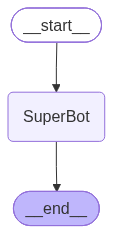

In [28]:
graph = StateGraph(State)

graph.add_node("SuperBot", superbot)
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder=graph.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [30]:
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi, my name is KJ, I like badminton"},config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hi KJ. Badminton is a fantastic sport, great for improving agility and hand-eye coordination. Do you play competitively, or more for fun and exercise?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 116, 'total_tokens': 151, 'completion_time': 0.111841499, 'completion_tokens_details': None, 'prompt_time': 0.014221837, 'prompt_tokens_details': None, 'queue_time': 0.047612426, 'total_time': 0.126063336}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a00436-ad7a-7a00-9faf-c0cd3b00315a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 116, 'output_tokens': 35, 'total_tokens': 151})]}}


In [34]:
config = {"configurable": {"thread_id": "4"}}

async for chunk in graph_builder.astream_events({'messages':"Hi, my name is KJ, I like badminton"},config, version="v2"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, my name is KJ, I like badminton'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a00439-9f0d-7473-b3e0-106879f49d25', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is KJ, I like badminton', additional_kwargs={}, response_metadata={}, id='b7af3db2-3de5-419c-834f-bec7c6959f8f')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a00439-9f54-7c91-8eec-b6977cb1ebd3', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:a5bc7dab-a17a-3986-1ef1-414135513177'}, 'parent_ids': ['01a00439-9f0d-7473-b3e0-106879f49d25']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content=